In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


##

In [67]:
# Dosyaları en temiz haliyle okuyalım
routes = pd.read_csv('routes.txt', skipinitialspace=True)
trips = pd.read_csv('trips.txt', skipinitialspace=True)
stop_times = pd.read_csv("stop_times.txt")

# Gereksiz sütunları atıp sadece ihtiyacımız olanları tutalım
routes = routes[['route_id', 'route_short_name', 'route_long_name']]

In [65]:
# Trips ve Routes'u route_id üzerinden birleştir
# Bu işlemle her seferin (trip) yanına gerçek otobüs numarası (short_name) gelir
df_birlesik = pd.merge(trips, routes, on='route_id', how='left')

In [66]:
# Gerçek otobüs numarasına (route_short_name) göre sayalım
en_islek_hatlar = df_birlesik.groupby(['route_short_name', 'route_long_name']).size().reset_index(name='toplam_sefer')

# En yüksek sefer sayısına göre sıralayalım
en_islek_hatlar = en_islek_hatlar.sort_values(by='toplam_sefer', ascending=False)

# İlk 10 sonucu görelim
print("--- İZMİR ESHOT EN YOĞUN HATLAR LİSTESİ ---")
print(en_islek_hatlar.head(10))

--- İZMİR ESHOT EN YOĞUN HATLAR LİSTESİ ---
     route_short_name                         route_long_name  toplam_sefer
203               565                  EVKA 4 - BORNOVA METRO           710
336               800         MENEMEN AKTARMA - BORNOVA METRO           658
251               680                 BOZYAKA - LOZAN MEYDANI           605
101               268                  DOĞANLAR - EVKA3 METRO           601
409               969       BALÇOVA - F.ALTAY AKTARMA MERKEZİ           534
24                 42                      ÇINARTEPE - GÜMRÜK           524
365               838       ŞİRİNYER AKTARMA MERKEZİ - GÜMRÜK           478
393               912  EGEKENT AKTARMA MERKEZİ - ALSANCAK GAR           463
217               599             M.ERENER - HALKAPINAR METRO           456
109               304                         TINAZTEPE-KONAK           446


In [70]:
stop_times["hour"] = stop_times["arrival_time"].str.split(":").str[0].astype(int)
stop_times = stop_times[stop_times["hour"] < 24]    ## hatalı verileri temizledim 25 gibi veriler olabilir

## Saatlere göre sefer yoğunluğu 

In [71]:
saatlik_yogunluk = stop_times["hour"].value_counts().sort_index()

## Görselleştirme

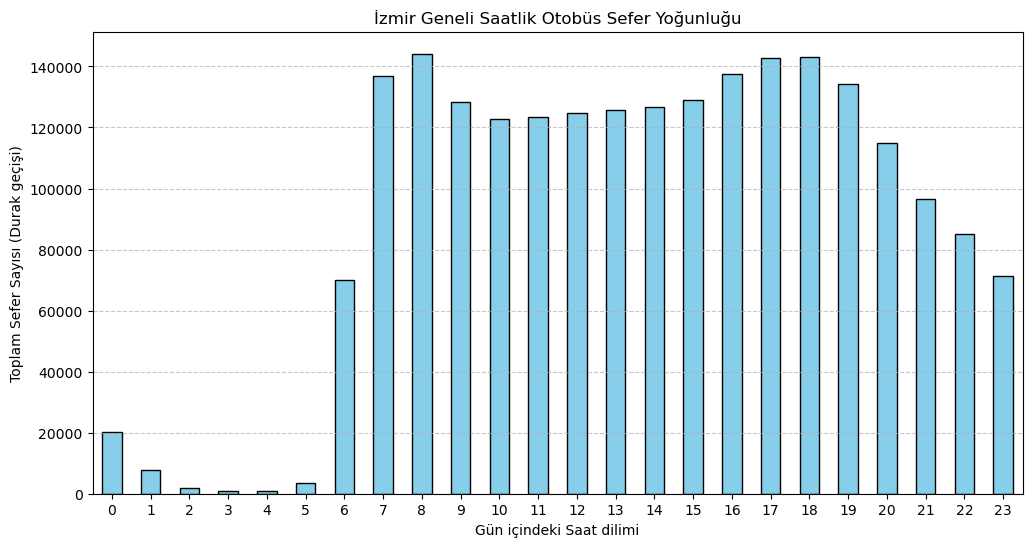

In [72]:
plt.figure(figsize=(12,6))
saatlik_yogunluk.plot(kind='bar', color= "skyblue", edgecolor = "black")
plt.title("İzmir Geneli Saatlik Otobüs Sefer Yoğunluğu")
plt.xlabel("Gün içindeki Saat dilimi")
plt.ylabel("Toplam Sefer Sayısı (Durak geçişi)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [73]:
## En yoğun saatlerde (sabah 08:00) engelli dostu araçların oranı, sakin saatlere göre daha mı az?

In [75]:
first_stops = stop_times[stop_times["stop_sequence"] == 1]
accessibility_analysis = pd.merge(first_stops, trips[["trip_id", "wheelchair_accessible"]], on="trip_id")

# 2. Sabah 08:00'deki engelli aracı oranına bakalım
rush_hour_8 = accessibility_analysis[accessibility_analysis["hour"] ==8 ]
accessibility_rate = rush_hour_8["wheelchair_accessible"].value_counts(normalize=True)*100

print(f"Sabah 08:00 seferlerinin %{accessibility_rate[1]:.2f}'i engelli dostu araçlar ile yapılıyor.")

Sabah 08:00 seferlerinin %100.00'i engelli dostu araçlar ile yapılıyor.
